# Savings Algorithm (Clarke-Wright) — TSP

Heuristique constructive gloutonne (Clarke & Wright, 1964).
Construit un tour en fusionnant itérativement les paires de villes
qui maximisent le **saving** $s(i,j) = c_{0i} + c_{0j} - c_{ij}$.

- **Complexité :** $O(n^2 \log n)$
- **Optimalité :** non garantie — gap typique 10–15%
- **Avantage :** fonctionne sur de très grandes instances ($n > 10^6$)

In [1]:
import math
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np

## 1. Génération de graphe

In [2]:
def generate_graph(n: int, seed: int | None = None) -> list[tuple[float, float]]:
    rng = random.Random(seed)
    return [(rng.uniform(0, 100), rng.uniform(0, 100)) for _ in range(n)]

## 2. Algorithme Clarke-Wright

In [3]:
def solve_tsp_clarke_wright(
    cities: list[tuple[float, float]],
) -> tuple[list[int], float]:
    """
    Clarke-Wright Savings Algorithm pour le TSP.

    cities[0] est le dépôt. Les autres villes sont les clients.
    Retourne : (tour, distance_totale)
    """
    n = len(cities)
    if n <= 1:
        return list(range(n)), 0.0
    if n == 2:
        return [0, 1], 2 * math.hypot(cities[0][0]-cities[1][0], cities[0][1]-cities[1][1])

    depot = 0

    def dist(i: int, j: int) -> float:
        dx = cities[i][0] - cities[j][0]
        dy = cities[i][1] - cities[j][1]
        return math.hypot(dx, dy)

    # ── Étape 1 : calcul des savings ──────────────────────────────────────────
    savings = []
    for i in range(1, n):
        for j in range(i + 1, n):
            s = dist(depot, i) + dist(depot, j) - dist(i, j)
            savings.append((s, i, j))
    savings.sort(reverse=True)  # ordre décroissant

    # ── Étape 2 : fusion gloutonne ────────────────────────────────────────────
    # routes[key] = liste ordonnée des villes (sans le dépôt)
    routes: dict[int, list[int]] = {i: [i] for i in range(1, n)}
    # endpoint_to_route[v] = clé de la route dont v est une extrémité
    endpoint_to_route: dict[int, int] = {i: i for i in range(1, n)}

    for s, i, j in savings:
        ri = endpoint_to_route.get(i)
        rj = endpoint_to_route.get(j)

        # i ou j n'est plus une extrémité, ou même route
        if ri is None or rj is None or ri == rj:
            continue

        route_i = routes[ri]
        route_j = routes[rj]

        # Orienter route_i pour que i soit en fin
        if route_i[-1] == i:
            pass
        elif route_i[0] == i:
            route_i.reverse()
        else:
            continue

        # Orienter route_j pour que j soit en début
        if route_j[0] == j:
            pass
        elif route_j[-1] == j:
            route_j.reverse()
        else:
            continue

        # Fusion : route_i → route_j
        new_route = route_i + route_j
        routes[ri] = new_route
        del routes[rj]

        # Mettre à jour les extrémités
        head, tail = new_route[0], new_route[-1]
        endpoint_to_route.pop(i, None)
        endpoint_to_route.pop(j, None)
        endpoint_to_route[head] = ri
        endpoint_to_route[tail] = ri

    # ── Étape 3 : assembler le tour final ─────────────────────────────────────
    final_route = list(routes.values())[0] if routes else []
    tour = [depot] + final_route
    total = (
        sum(dist(tour[k], tour[k + 1]) for k in range(len(tour) - 1))
        + dist(tour[-1], tour[0])
    )
    return tour, total

## 3. Visualisation

In [4]:
def plot_tour(cities, tour, distance, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    tour_closed = tour + [tour[0]]
    for k in range(len(tour_closed) - 1):
        i, j = tour_closed[k], tour_closed[k + 1]
        ax.plot([cities[i][0], cities[j][0]], [cities[i][1], cities[j][1]],
                "b-", linewidth=1.2, alpha=0.7)
    xs = [c[0] for c in cities]
    ys = [c[1] for c in cities]
    ax.scatter(xs, ys, c="red", s=60, zorder=5)
    for idx, (cx, cy) in enumerate(cities):
        ax.annotate(str(idx), (cx, cy), textcoords="offset points",
                    xytext=(5, 5), fontsize=8)
    ax.scatter([cities[tour[0]][0]], [cities[tour[0]][1]],
               c="green", s=150, zorder=6, marker="*", label="Dépôt")
    ax.set_title(f"{title}\nDistance : {distance:.2f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Paramètres

In [5]:
N_CITIES_LIST = [1, 10, 100, 1_000, 10_000, 1_000_000]
SEED          = 42

## 5. Exécution — résultats par taille


  n = 1 villes
  Distance : 0.000
  Temps    : 0.000s


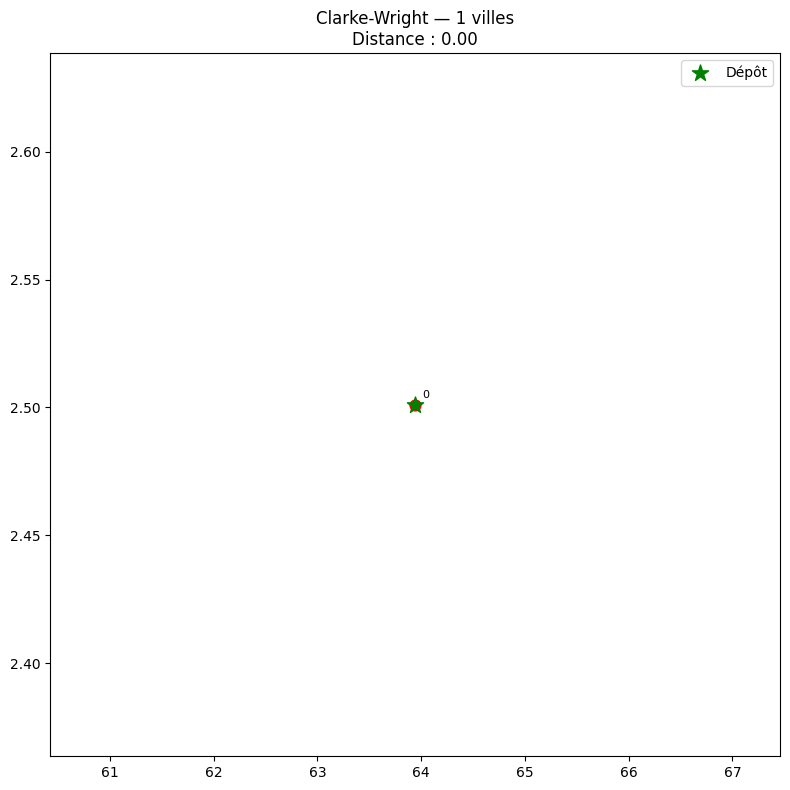


  n = 10 villes
  Distance : 264.139
  Temps    : 0.000s


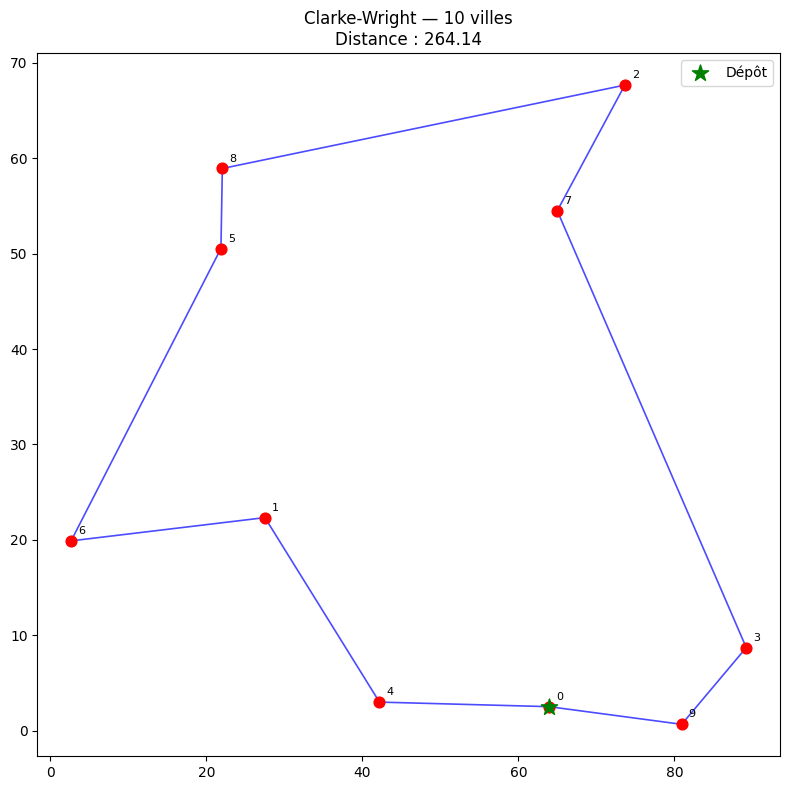


  n = 100 villes
  Distance : 851.028
  Temps    : 0.004s


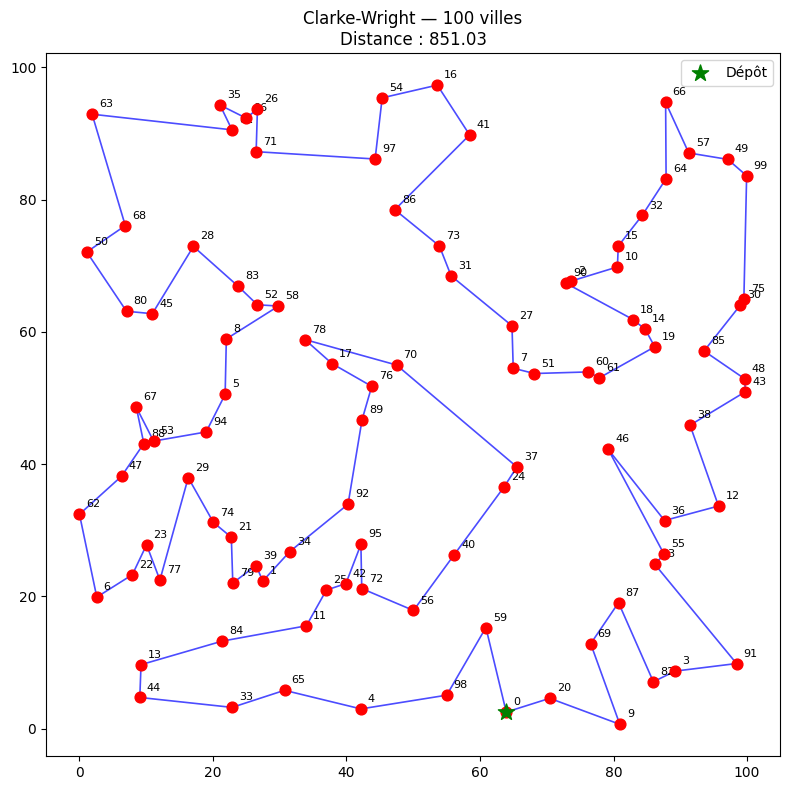


  n = 1,000 villes


  Distance : 2512.538
  Temps    : 0.772s


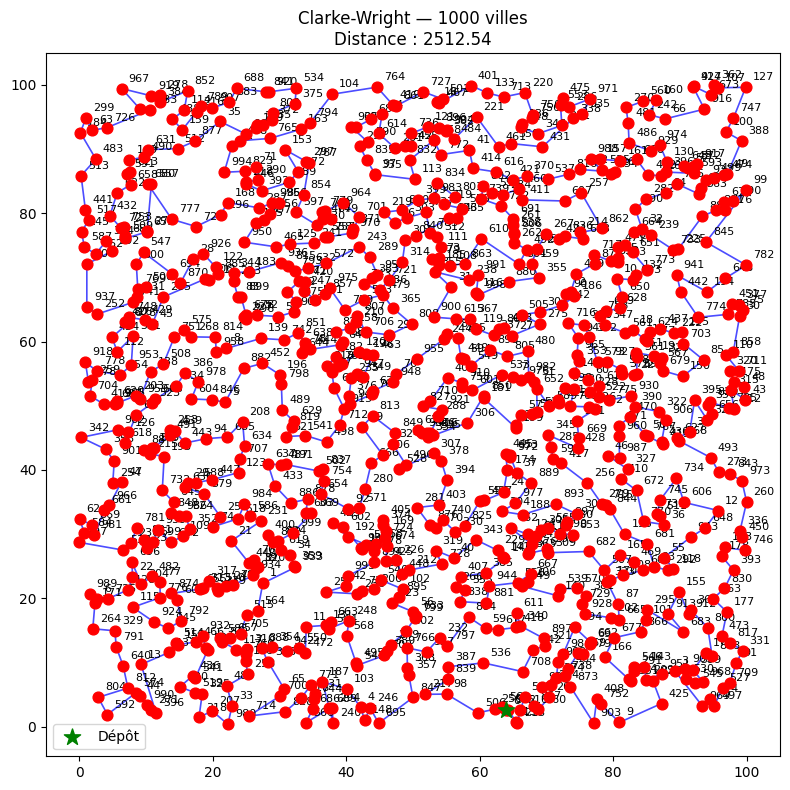


  n = 10,000 villes


  Distance : 8011.321
  Temps    : 130.199s

  n = 1,000,000 villes
  SKIP — 1000000²/2 = 500,000,000,000 paires de savings (hors mémoire)


In [6]:
for N_CITIES in N_CITIES_LIST:
    print(f"\n{'='*55}")
    print(f"  n = {N_CITIES:,} villes")
    print(f"{'='*55}")

    if N_CITIES > 10_000:
        # Clarke-Wright génère n²/2 paires de savings.
        # n=1 000 000 → 5×10¹¹ paires : hors mémoire et hors temps.
        # L'implémentation standard O(n² log n) est limitée à ~10 000 villes.
        print(f"  SKIP — {N_CITIES}²/2 = {N_CITIES**2//2:,} paires de savings (hors mémoire)")
        continue

    cities = generate_graph(N_CITIES, seed=SEED)
    t0 = time.perf_counter()
    tour, distance = solve_tsp_clarke_wright(cities)
    elapsed = time.perf_counter() - t0

    print(f"  Distance : {distance:.3f}")
    print(f"  Temps    : {elapsed:.3f}s")

    if tour and N_CITIES <= 1000:
        plot_tour(cities, tour, distance, f"Clarke-Wright — {N_CITIES} villes")

## 6. Benchmark — performances et graphiques

In [7]:
BENCHMARK_SIZES = [1, 10, 100, 1_000, 10_000, 100_000]
results = []

for n in BENCHMARK_SIZES:
    print(f"[n={n:>7}] ", end="", flush=True)
    if n > 10_000:
        print(f"SKIP — {n}²/2 = {n**2//2:,} paires de savings (hors mémoire)")
        continue
    cities = generate_graph(n, seed=SEED)
    tracemalloc.start()
    t0 = time.perf_counter()
    tour, distance = solve_tsp_clarke_wright(cities)
    elapsed = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"dist={distance:.2f}  t={elapsed:.3f}s  mém={peak/1e6:.1f}MB")
    results.append({"n": n, "distance": distance, "temps": elapsed, "memoire": peak/1e6})

[n=      1] 

dist=0.00  t=0.000s  mém=0.0MB
[n=     10] 

dist=264.14  t=0.000s  mém=0.0MB
[n=    100] 

dist=851.03  t=0.035s  mém=0.4MB
[n=   1000] 

dist=2512.54  t=1.934s  mém=63.0MB
[n=  10000] 

dist=8011.32  t=270.941s  mém=6408.0MB
[n= 100000] 

SKIP — 100000²/2 = 5,000,000,000 paires de savings (hors mémoire)


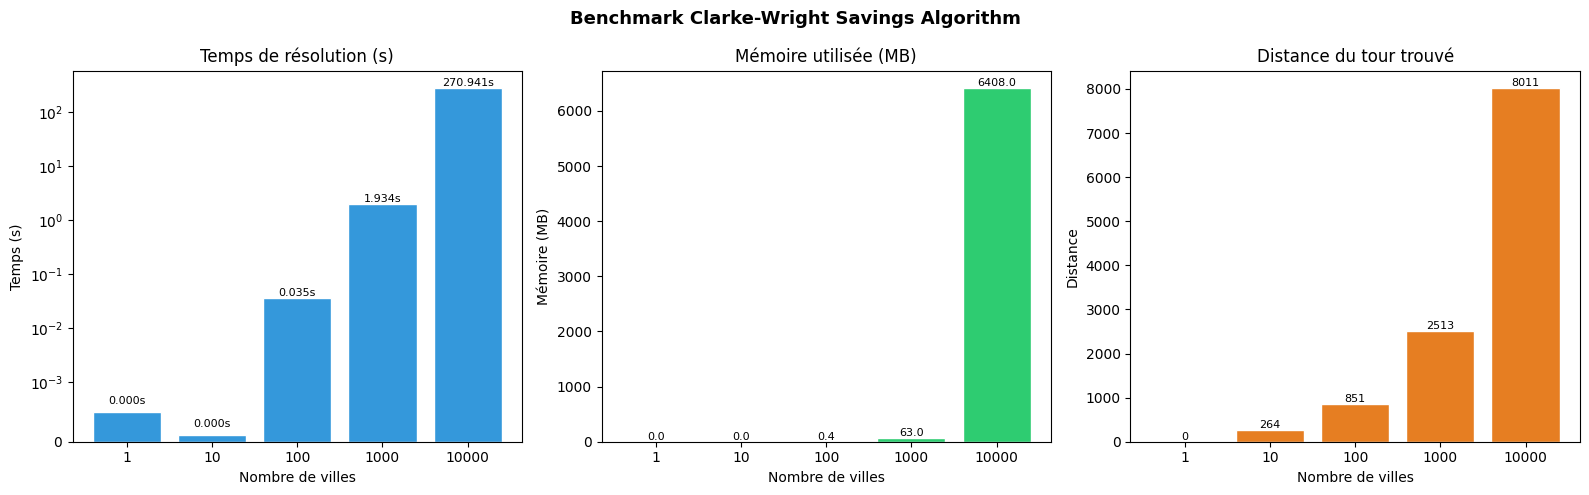


Modèle : t = 1.3560e-06 × n^2.081
  n=   1,000,000 → 4173167.9s
  n=  10,000,000 → 503305839.4s


In [8]:
labels  = [str(r["n"]) for r in results]
temps   = [r["temps"]   for r in results]
memoire = [r["memoire"] for r in results]
dists   = [r["distance"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Benchmark Clarke-Wright Savings Algorithm", fontsize=13, fontweight="bold")

# Temps
ax = axes[0]
bars = ax.bar(labels, temps, color="#3498db", edgecolor="white")
ax.set_title("Temps de résolution (s)")
ax.set_xlabel("Nombre de villes")
ax.set_ylabel("Temps (s)")
ax.set_yscale("symlog", linthresh=0.001)
for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f"{r['temps']:.3f}s", ha="center", va="bottom", fontsize=8)

# Mémoire
ax = axes[1]
bars = ax.bar(labels, memoire, color="#2ecc71", edgecolor="white")
ax.set_title("Mémoire utilisée (MB)")
ax.set_xlabel("Nombre de villes")
ax.set_ylabel("Mémoire (MB)")
for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{r['memoire']:.1f}", ha="center", va="bottom", fontsize=8)

# Distance
ax = axes[2]
bars = ax.bar(labels, dists, color="#e67e22", edgecolor="white")
ax.set_title("Distance du tour trouvé")
ax.set_xlabel("Nombre de villes")
ax.set_ylabel("Distance")
for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{r['distance']:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Prédiction de temps par loi de puissance
known_n = np.array([r["n"] for r in results if r["n"] >= 10])
known_t = np.array([r["temps"] for r in results if r["n"] >= 10])
b, log_a = np.polyfit(np.log(known_n), np.log(known_t + 1e-9), 1)
a = np.exp(log_a)
print(f"\nModèle : t = {a:.4e} × n^{b:.3f}")
for n_pred in [1_000_000, 10_000_000]:
    t_pred = a * n_pred ** b
    print(f"  n={n_pred:>12,} → {t_pred:.1f}s")